Deep Learning 22AIE304

KORRAPATI NAGA HASMITHA
CH.SC.U4AIE24037


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


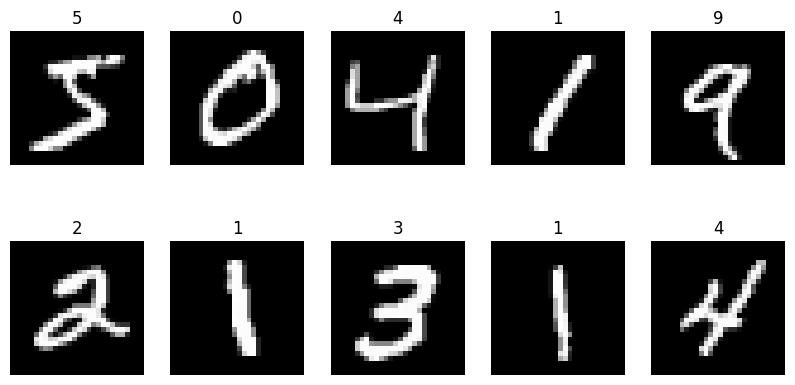

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (216.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36 (148.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_split=0.1
)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9796 - loss: 0.0654 - val_accuracy: 0.9810 - val_loss: 0.0731
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9818 - loss: 0.0583 - val_accuracy: 0.9843 - val_loss: 0.0680
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9835 - loss: 0.0532 - val_accuracy: 0.9818 - val_loss: 0.0702
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9835 - loss: 0.0524 - val_accuracy: 0.9840 - val_loss: 0.0634
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9842 - loss: 0.0500 - val_accuracy: 0.9822 - val_loss: 0.0707
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9844 - loss: 0.0510 - val_accuracy: 0.9842 - val_loss: 0.0674
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9857 - loss: 0.0473 - val_accuracy: 0.9830 - val_loss: 0.0629
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9862 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy =", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9813 - loss: 0.0763
Test Accuracy = 0.9812999963760376


In [ ]:
prediction = model.predict(x_test[:1])

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Digit: 7
Actual Digit: 7


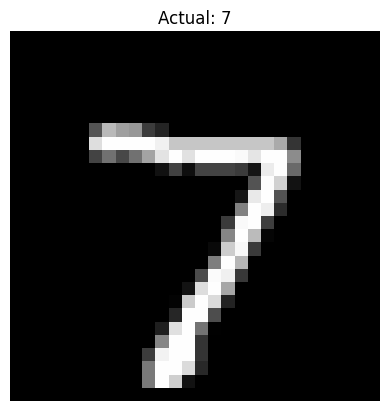

In [ ]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Actual: {y_test[0]}")
plt.axis('off')
plt.show()

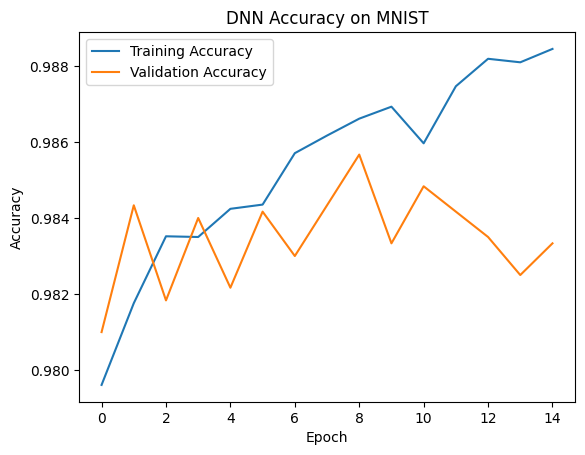

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('DNN Accuracy on MNIST')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:

def step(x):
    if x >= 0:
        return 1
    return 0

def AND_gate(x1, x2):
    w1 = 1
    w2 = 1
    b = -1.5

    net = w1*x1 + w2*x2 + b

    return step(net)

for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1, x2, "->", AND_gate(x1,x2))

0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1


In [ ]:
def OR_gate(x1, x2):
    w1 = 1
    w2 = 1
    b = -0.5

    net = w1*x1 + w2*x2 + b

    return step(net)

for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1, x2, "->", OR_gate(x1,x2))

0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [ ]:
def NOT_gate(x):
    w = -1
    b = 0.5

    net = w*x + b

    return step(net)

print("NOT(0) =", NOT_gate(0))
print("NOT(1) =", NOT_gate(1))

NOT(0) = 1
NOT(1) = 0


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR inputs
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# XOR outputs
y = np.array([0,1,1,0])

# MLP Model
model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X, y, epochs=500, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)

print("Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 1.0


In [ ]:
predictions = model.predict(X)

for i in range(len(X)):
    print(X[i], "->", round(predictions[i][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


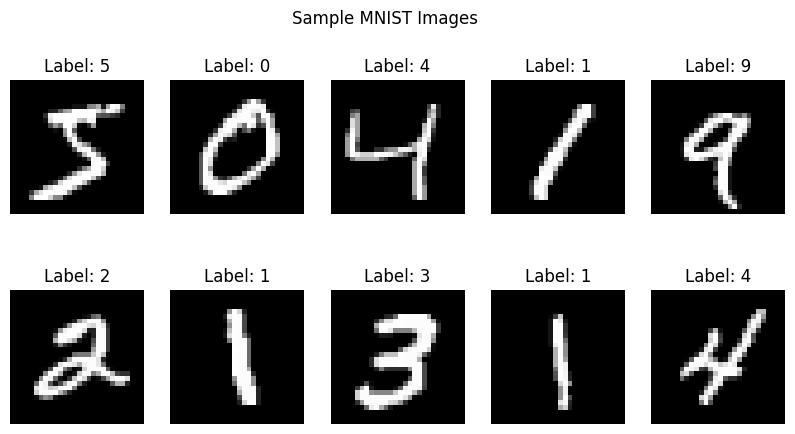

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8956 - loss: 0.3423 - val_accuracy: 0.9712 - val_loss: 0.0982
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9509 - loss: 0.1628 - val_accuracy: 0.9747 - val_loss: 0.0830
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9618 - loss: 0.1294 - val_accuracy: 0.9757 - val_loss: 0.0805
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9665 - loss: 0.1113 - val_accuracy: 0.9765 - val_loss: 0.0810
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9718 - loss: 0.0950 - val_accuracy: 0.9792 - val_loss: 0.0782
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9728 - loss: 0.0893 - val_accuracy: 0.9792 - val_loss: 0.0714
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9750 - loss: 0.0813 - val_accuracy: 0.9820 - val_loss: 0.0722
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9779 - loss: 0

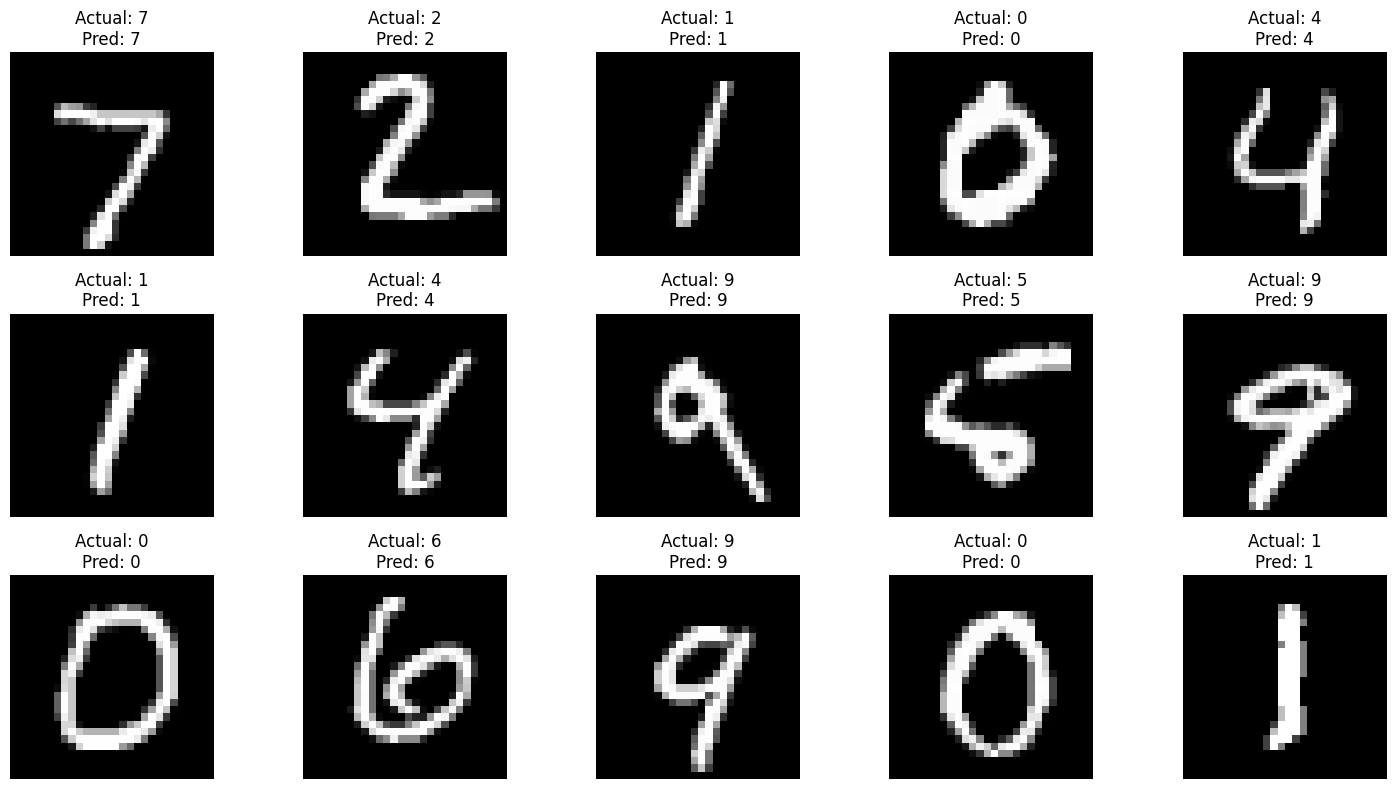

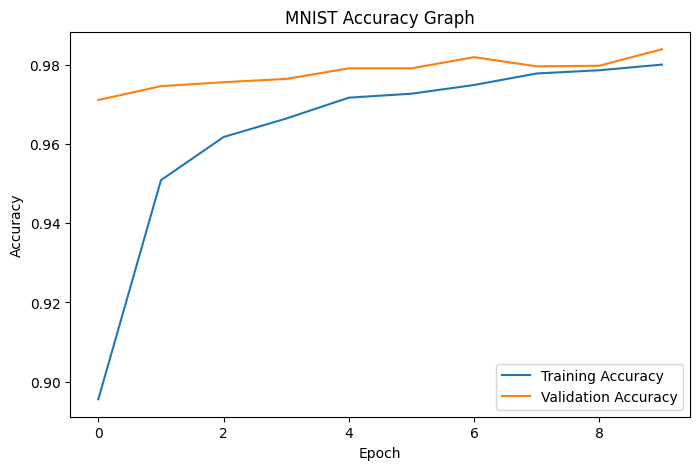

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout



(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)


plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Sample MNIST Images")
plt.show()



x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0



model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])



model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



model.summary()



history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)


loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy =", accuracy * 100, "%")



predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)



plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(x_test[i], cmap='gray')

    plt.title(
        f"Actual: {y_test[i]}\nPred: {predicted_labels[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MNIST Accuracy Graph')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


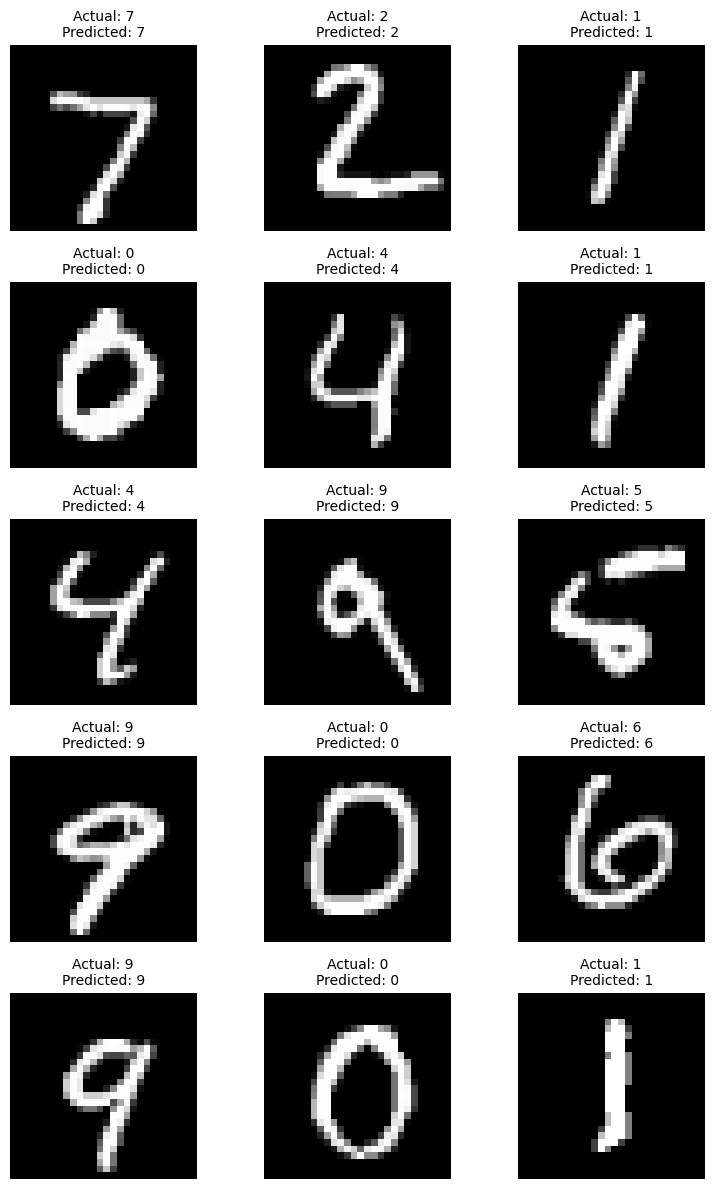

In [ ]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(8, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i], cmap='gray')
    ax.set_title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}",
        fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual Label": y_test[:20],
    "Predicted Label": predicted_labels[:20]
})

print(results)

    Actual Label  Predicted Label
0              7                7
1              2                2
2              1                1
3              0                0
4              4                4
5              1                1
6              4                4
7              9                9
8              5                5
9              9                9
10             0                0
11             6                6
12             9                9
13             0                0
14             1                1
15             5                5
16             9                9
17             7                7
18             3                3
19             4                4


In [ ]:
import pandas as pd

accuracy_table = pd.DataFrame({
    'Epoch': range(1, len(history.history['accuracy']) + 1),
    'Training Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy']
})

print(accuracy_table)

    Epoch  Training Accuracy  Validation Accuracy
0       1           0.979611             0.981000
1       2           0.981759             0.984333
2       3           0.983519             0.981833
3       4           0.983500             0.984000
4       5           0.984241             0.982167
5       6           0.984352             0.984167
6       7           0.985704             0.983000
7       8           0.986167             0.984333
8       9           0.986611             0.985667
9      10           0.986926             0.983333
10     11           0.985963             0.984833
11     12           0.987463             0.984167
12     13           0.988185             0.983500
13     14           0.988093             0.982500
14     15           0.988444             0.983333


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, predicted_labels)

cm_df = pd.DataFrame(
    cm,
    index=[0,1,2,3,4,5,6,7,8,9],
    columns=[0,1,2,3,4,5,6,7,8,9]
)

print("Confusion Matrix")
print(cm_df)

Confusion Matrix
     0     1     2    3    4    5    6     7    8    9
0  974     1     1    0    1    1    1     0    0    1
1    3  1126     0    1    0    1    2     1    1    0
2    3     2  1012    3    2    0    1     7    1    1
3    0     0     2  995    0    4    0     4    3    2
4    1     0     1    0  966    0    5     2    0    7
5    2     0     0   11    1  870    5     1    2    0
6    7     2     0    1    3    1  944     0    0    0
7    2     1     8    1    0    0    0  1010    2    4
8   11     0     3    5    4    3    4     4  932    8
9    4     2     0    2   13    1    0     3    0  984
